Name- Aditya Makkar          
Subject- Methods of Prediction           
Reg. No- GH1057829

# 1.) Introduction


> ##### Chess is a widely played game, gaining popularity over the years. However, due to its technical nature, it can be convereted into a structured visual environment. A chess board is 8x8, and due to permutations and combinations, can have an estimated of 10^50 no. of different legal positions, almost as much as the no. of atoms in the entire planet! 

> ##### However, even with the large no. of positions available, each position can be mapped to a specific FEN Notation. 

> 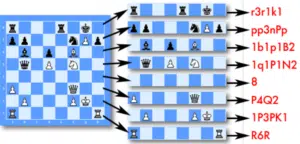

> ##### Each row can have it's own syntax to represent what pieces are on the board or not. Then the 8 rows are combined together to form a long string indicating the position of the entire board.

> ##### Example- rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0

### Objective
> ##### We have 13 possible classes to define each square(6 white pieces + 6 black pieces + empty space). We have to apply classification to each of the 64 squares, and reconstruct the complete board position. 

# 2.) Dataset and Tools Used


### 2.1 Dataset
> * ##### Dataset- Kaggle Chess positions, 100000 synthetic chessboard images(Kovarkin, 2018).  
> * ##### Each image is of 400x400 Pixels, and has a associated FEN based string.
> * ##### 32 different types of boards, and 28 different types of chess pieces in terms of design are there in the Dataset

### 2.2 Tools Used

> * ##### TensorFlow, Keras, Scikit Learn
> * ##### Python-chess, PIL

# 3.) Dataset Exploration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
train_path = "train"
test_path = "test"

train_images = os.listdir(train_path)
test_images = os.listdir(test_path)

print("Training images:", len(train_images))
print("Testing images:", len(test_images))

Training images: 80000
Testing images: 20000


Filename: 1b1B1b2-2pK2q1-4p1rB-7k-8-8-3B4-3rb3.jpeg
Image size: (400, 400)
Image mode: RGB


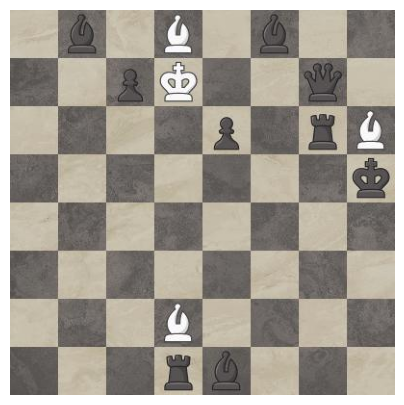

In [3]:
# Inspect a sample image
sample_file = train_images[0]

print("Filename:", sample_file)

sample_image = Image.open(os.path.join(train_path, sample_file))

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off");

> * ##### We have 2 folders, 80000 training images, 20000 testing images
> * ##### The fen notation of the images is their filename
> * ##### As we discussed earlier, 400x400 pixels, and RGB format for each picture.

# 4.) Label Generation and Image Preprocessing


### 4.1) Mapping each chess piece to class.
> * ##### The filename contains the FEN notation for the specific chess position image. 
> * ##### We first map all the letters possible in a notation to 13 respective classes -> We then parse the filename, and generate the labels for each of the 64 squares of the chessboard
> * ##### These labels are the target values for CNN training 


In [4]:
class_map = {
    ".": 0,
    "P": 1, "N": 2, "B": 3, "R": 4, "Q": 5, "K": 6,
    "p": 7, "n": 8, "b": 9, "r": 10, "q": 11, "k": 12
}

### Labels-
> 0  empty, 1  White pawn, 2  White knight, 3  White bishop, 4  White rook, 5  White queen, 6  White king, 7  Black pawn, 8  Black knight, 9  Black bishop, 10 Black rook, 11 Black queen, 12 Black king

In [5]:
def position_to_labels(filename):
    position = os.path.splitext(filename)[0]
    ranks = position.split("-")
    
    labels = []
    
    for rank in ranks:
        for char in rank:
            if char.isdigit():
                labels.extend([0] * int(char))
            else:
                labels.append(class_map[char])
    
    return labels

In [6]:
# Here I am testing the above logic on a sample image
sample_labels = position_to_labels(sample_file)

print("Number of squares:", len(sample_labels))
print("Labels:", sample_labels)

Number of squares: 64
Labels: [0, 9, 0, 3, 0, 9, 0, 0, 0, 0, 7, 6, 0, 0, 11, 0, 0, 0, 0, 0, 7, 0, 10, 3, 0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 10, 9, 0, 0, 0]


### 4.2) Validation on whether the labels generated are accurate/match the original file name

In [7]:
reverse_map = {v: k for k, v in class_map.items()}

def labels_to_position(labels):
    ranks = []
    
    for i in range(8):
        rank = labels[i * 8:(i + 1) * 8]
        encoded_rank = ""
        empty_count = 0
        
        for label in rank:
            if label == 0:
                empty_count += 1
            else:
                if empty_count > 0:
                    encoded_rank += str(empty_count)
                    empty_count = 0
                encoded_rank += reverse_map[label]
        
        if empty_count > 0:
            encoded_rank += str(empty_count)
        
        ranks.append(encoded_rank)
    
    return "-".join(ranks)

original_position = os.path.splitext(sample_file)[0]
reconstructed_position = labels_to_position(sample_labels)

print("Original:     ", original_position)
print("Reconstructed:", reconstructed_position)
print("Match:", original_position == reconstructed_position)

Original:      1b1B1b2-2pK2q1-4p1rB-7k-8-8-3B4-3rb3
Reconstructed: 1b1B1b2-2pK2q1-4p1rB-7k-8-8-3B4-3rb3
Match: True


### 4.3) Image preprocessing into seperate 64 indiviual squares/images(labeled)

In [8]:
def split_board(image):
    squares = []
    square_size = image.size[0] // 8
    
    for row in range(8):
        for col in range(8):
            left = col * square_size
            upper = row * square_size
            right = left + square_size
            lower = upper + square_size
            
            square = image.crop((left, upper, right, lower))
            squares.append(square)
    
    return squares

In [9]:
sample_squares = split_board(sample_image)

print("Number of squares:", len(sample_squares))
print("Square size:", sample_squares[0].size)

Number of squares: 64
Square size: (50, 50)


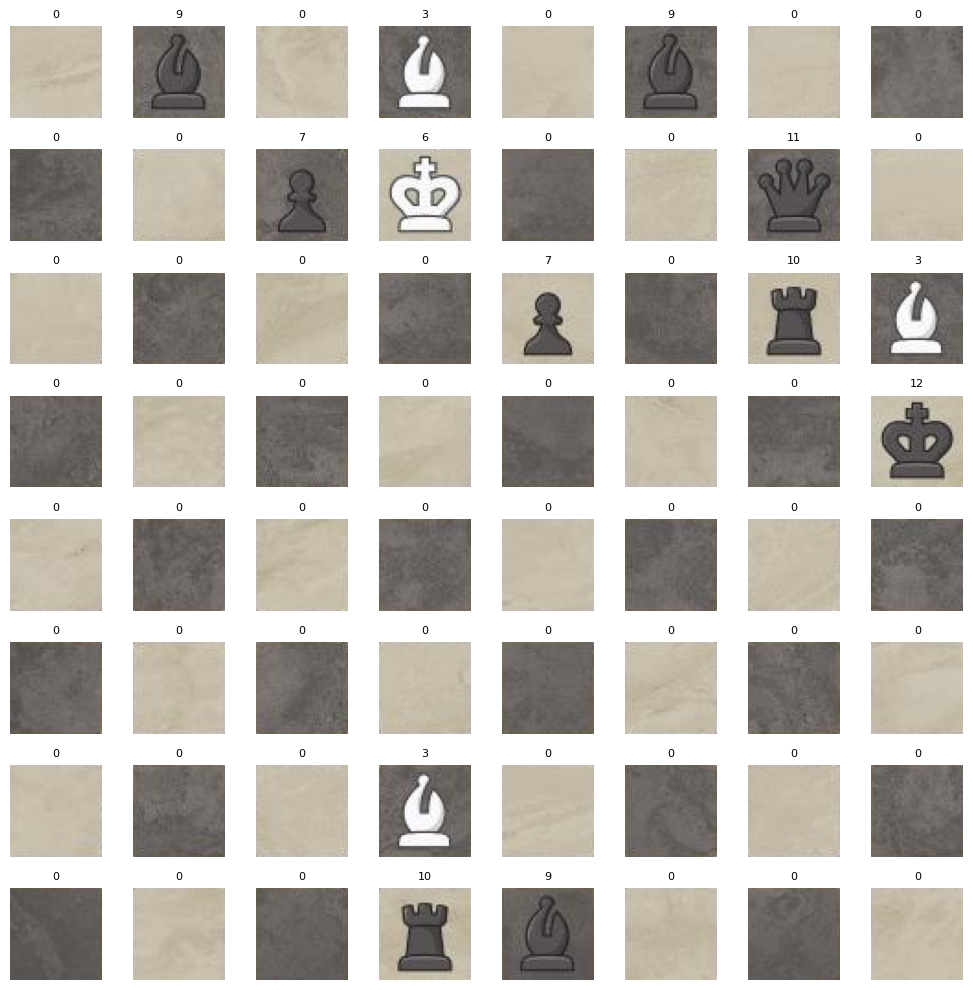

In [10]:
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for i, square in enumerate(sample_squares):
    axes[i // 8, i % 8].imshow(square)
    axes[i // 8, i % 8].axis("off")
    axes[i // 8, i % 8].set_title(str(sample_labels[i]), fontsize=8)

plt.tight_layout()

# 5.) CNN Dataset Preparation
#### The reason we use CNN is that this is a an Image Recognition Problem, and CNN's excel in that. The CNN can learn things like Edges, shapes, pieces strutures, and classify it easily. Moreover, because of convulation and pooling, we'll be able to efficiently process the images.


### 5.1) Input Prepartion
* Converting the images into numerical tensors
* Normalizing pixel values btwn 0-1
* Preparing corresponding target labels

In [11]:
import tensorflow as tf

X_sample = np.array([np.array(square) for square in sample_squares], dtype=np.float32) / 255.0
y_sample = np.array(sample_labels, dtype=np.int32)

print("Image data shape:", X_sample.shape)
print("Label data shape:", y_sample.shape)
print("Pixel range:", X_sample.min(), "to", X_sample.max())

c:\Users\adity\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.1)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


Image data shape: (64, 50, 50, 3)
Label data shape: (64,)
Pixel range: 0.039215688 to 1.0


> #### Our input is of 64 images, 50x50 pixels and of 3 layers(RGB) - X_Sample and Our target variable is of 64 classed labels- Y_Sample

In [12]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

all_train_files = [
    os.path.join(train_path, f)
    for f in train_images
    if f.lower().endswith((".jpeg", ".jpg", ".png"))
]

train_files, val_files = train_test_split(
    all_train_files,
    test_size=0.1,
    random_state=42
)

print("Training boards:", len(train_files))
print("Validation boards:", len(val_files))


def load_board(filepath):
    filepath = filepath.numpy().decode("utf-8")
    
    image = Image.open(filepath).convert("RGB")
    squares = split_board(image)
    
    X = np.array([np.array(square) for square in squares], dtype=np.float32) / 255.0
    y = np.array(position_to_labels(os.path.basename(filepath)), dtype=np.int32)
    
    return X, y


def load_board_tf(filepath):
    X, y = tf.py_function(
        load_board,
        [filepath],
        [tf.float32, tf.int32]
    )
    
    X.set_shape((64, 50, 50, 3))
    y.set_shape((64,))
    
    return X, y

# Here I am creating TensorFlow datasets for training and validation using the file paths of the chessboard images on the training set(80k images)
#  Each board image is loaded and split into 64 individual squares. These are used for training the CNN.
train_ds = tf.data.Dataset.from_tensor_slices(train_files)
val_ds = tf.data.Dataset.from_tensor_slices(val_files)

train_ds = train_ds.map(load_board_tf, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_board_tf, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.unbatch()
val_ds = val_ds.unbatch()

# Batch for CNN training
train_ds = train_ds.batch(64).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(64).prefetch(tf.data.AUTOTUNE)

print("CNN input shape:", (50, 50, 3))
print("Number of classes:", 13)

Training boards: 72000
Validation boards: 8000
CNN input shape: (50, 50, 3)
Number of classes: 13


In [13]:
# Build the baseline CNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,429 (3.86 MB)

 Trainable params: 1,012,429 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#using smaller datasets for training and validation as we dont have the computing power to train on the entire dataset. 

dev_train_files = train_files[:10000]
dev_val_files = val_files[:2000]

dev_train_ds = (
    tf.data.Dataset.from_tensor_slices(dev_train_files)
    .map(load_board_tf, num_parallel_calls=tf.data.AUTOTUNE)
    .unbatch()
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

dev_val_ds = (
    tf.data.Dataset.from_tensor_slices(dev_val_files)
    .map(load_board_tf, num_parallel_calls=tf.data.AUTOTUNE)
    .unbatch()
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

print("Development training boards:", len(dev_train_files))
print("Development validation boards:", len(dev_val_files))

Development training boards: 10000
Development validation boards: 2000


In [15]:
#Our baseline CNN
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

baseline_history = model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10


c:\Users\adity\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


10000/10000 ━━━━━━━━━━━━━━━━━━━━ 233s 23ms/step - accuracy: 0.9972 - loss: 0.0116 - val_accuracy: 1.0000 - val_loss: 4.6567e-06
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 237s 24ms/step - accuracy: 0.9993 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 3.2024e-05


* 2 Epochs were enough, early stopping made us realise this.
* 10000 images for training/ 2000 for Validation.

# 6.) Experimental Evaluation
> ### Our goal here is to figure out whether a simpler CNN model can solve this problem, and realistically how much model complexity do we need for this image classification.

In [16]:
# Experiment 3: further reduce CNN capacity

exp3_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),
    
    tf.keras.layers.Conv2D(8, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(16, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

exp3_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

exp3_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

exp3_history = exp3_model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[exp3_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 94s 9ms/step - accuracy: 0.9958 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 2.0381e-04
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 90s 9ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 2.4261e-05
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 72s 7ms/step - accuracy: 0.9998 - loss: 7.4325e-04 - val_accuracy: 1.0000 - val_loss: 1.6798e-05
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 1.0000 - loss: 2.5349e-06 - val_accuracy: 1.0000 - val_loss: 4.2107e-08
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 84s 8ms/step - accuracy: 0.9999 - loss: 6.3745e-04 - val_accuracy: 1.0000 - val_loss: 5.4154e-07


In [17]:
# Experiment 4: aggressive model capacity reduction

exp4_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),
    
    tf.keras.layers.Conv2D(4, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(8, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

exp4_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

exp4_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

exp4_history = exp4_model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[exp4_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9932 - loss: 0.0294 - val_accuracy: 1.0000 - val_loss: 2.3517e-04
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9998 - loss: 8.0395e-04 - val_accuracy: 1.0000 - val_loss: 4.1822e-05
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9999 - loss: 6.2895e-04 - val_accuracy: 1.0000 - val_loss: 3.4572e-06
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9999 - loss: 6.7220e-04 - val_accuracy: 1.0000 - val_loss: 2.2024e-06
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 51s 5ms/step - accuracy: 0.9999 - loss: 3.2895e-04 - val_accuracy: 1.0000 - val_loss: 9.2875e-07
Epoch 6/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.9998 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 1.3085e-05


In [18]:
# Experiment 5: larger convolutional kernels

exp5_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),

    tf.keras.layers.Conv2D(32, (5, 5), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (5, 5), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

exp5_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

exp5_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

exp5_history = exp5_model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[exp5_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 260s 26ms/step - accuracy: 0.9958 - loss: 0.0174 - val_accuracy: 1.0000 - val_loss: 7.3523e-05
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 260s 26ms/step - accuracy: 0.9994 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 2.9090e-06
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 264s 26ms/step - accuracy: 0.9997 - loss: 0.0016 - val_accuracy: 0.9998 - val_loss: 6.1661e-04


In [19]:
# Experiment 5: single convolutional block

exp5_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

exp5_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

exp5_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

exp5_history = exp5_model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[exp5_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 338s 34ms/step - accuracy: 0.9971 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 7.2920e-05
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 353s 35ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 8.2946e-06
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 277s 28ms/step - accuracy: 0.9996 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 6.3906e-06
Epoch 4/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 276s 28ms/step - accuracy: 0.9997 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 1.8138e-06
Epoch 5/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 275s 28ms/step - accuracy: 1.0000 - loss: 3.9693e-04 - val_accuracy: 1.0000 - val_loss: 3.9301e-05


In [20]:
# Experiment: reduce square resolution from 50x50 to 25x25

def load_board_25(filepath):
    X, y = load_board(filepath)
    X = tf.image.resize(X, (25, 25))
    return X, y


def load_board_25_tf(filepath):
    X, y = tf.py_function(
        load_board_25,
        [filepath],
        [tf.float32, tf.int32]
    )
    
    X.set_shape((64, 25, 25, 3))
    y.set_shape((64,))
    
    return X, y


dev_train_25_ds = (
    tf.data.Dataset.from_tensor_slices(dev_train_files)
    .map(load_board_25_tf, num_parallel_calls=tf.data.AUTOTUNE)
    .unbatch()
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

dev_val_25_ds = (
    tf.data.Dataset.from_tensor_slices(dev_val_files)
    .map(load_board_25_tf, num_parallel_calls=tf.data.AUTOTUNE)
    .unbatch()
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)


# Build the same baseline CNN for 25x25 inputs
resolution_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(25, 25, 3)),
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(13, activation="softmax")
])

resolution_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resolution_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

resolution_history = resolution_model.fit(
    dev_train_25_ds,
    validation_data=dev_val_25_ds,
    epochs=10,
    callbacks=[resolution_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 71s 7ms/step - accuracy: 0.9939 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 1.0801e-04
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 73s 7ms/step - accuracy: 0.9997 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 1.5380e-05
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 89s 9ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 5.4510e-05


In [22]:
# Experiment: evaluate baseline CNN on noisy validation images

def add_gaussian_noise(images, labels):
    noise = tf.random.normal(
        shape=tf.shape(images),
        mean=0.0,
        stddev=0.35
    )
    noisy_images = tf.clip_by_value(images + noise, 0.0, 1.0)
    return noisy_images, labels


noisy_val_ds = (
    dev_val_ds
    .map(add_gaussian_noise, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Evaluate the trained baseline model on noisy images
noisy_results = model.evaluate(noisy_val_ds)

print("Noisy validation loss:", noisy_results[0])
print("Noisy validation accuracy:", noisy_results[1])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9880 - loss: 0.0616
Noisy validation loss: 0.06162993237376213
Noisy validation accuracy: 0.9879531264305115


In [24]:
# Experiment: increased image brightness

def change_brightness(images, labels):
    bright_images = tf.image.adjust_brightness(images, delta=0.2)
    bright_images = tf.clip_by_value(bright_images, 0.0, 1.0)
    return bright_images, labels


bright_val_ds = (
    dev_val_ds
    .map(change_brightness, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

bright_results = model.evaluate(bright_val_ds)

print("Brightness-adjusted validation loss:", bright_results[0])
print("Brightness-adjusted validation accuracy:", bright_results[1])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9924 - loss: 0.0232
Brightness-adjusted validation loss: 0.02319370023906231
Brightness-adjusted validation accuracy: 0.9923984408378601


In [26]:
# Robustness experiments: image rotation and darkening

# Rotation: random rotation within ±10 degrees
rotation_layer = tf.keras.layers.RandomRotation(
    factor=50 / 360,
    fill_mode="nearest"
)

def rotate_images(images, labels):
    rotated = rotation_layer(images, training=True)
    return rotated, labels


# Darkening: reduce brightness
def darken_images(images, labels):
    darkened = tf.image.adjust_brightness(images, delta=-0.2)
    darkened = tf.clip_by_value(darkened, 0.0, 1.0)
    return darkened, labels


# Create transformed validation datasets
rotated_val_ds = (
    dev_val_ds
    .map(rotate_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

darkened_val_ds = (
    dev_val_ds
    .map(darken_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)


# Evaluate the baseline model
rotated_results = model.evaluate(rotated_val_ds, verbose=1)
darkened_results = model.evaluate(darkened_val_ds, verbose=1)

print("\nRotated validation accuracy:", rotated_results[1])
print("Rotated validation loss:", rotated_results[0])

print("\nDarkened validation accuracy:", darkened_results[1])
print("Darkened validation loss:", darkened_results[0])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9273 - loss: 0.6531
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9382 - loss: 0.3706

Rotated validation accuracy: 0.9272656440734863
Rotated validation loss: 0.6530677676200867

Darkened validation accuracy: 0.938156247138977
Darkened validation loss: 0.37057968974113464


In [27]:
# Experiment: Gaussian blur robustness

def gaussian_kernel(size=9, sigma=2.0):
    x = tf.range(-(size // 2), size // 2 + 1, dtype=tf.float32)
    xx, yy = tf.meshgrid(x, x)

    kernel = tf.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= tf.reduce_sum(kernel)

    return kernel


def blur_images(images, labels):
    kernel = gaussian_kernel(9, 2.0)
    kernel = kernel[:, :, tf.newaxis, tf.newaxis]

    # Apply the same blur independently to each RGB channel
    kernel = tf.tile(kernel, [1, 1, 3, 1])

    blurred = tf.nn.depthwise_conv2d(
        images,
        kernel,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )

    return blurred, labels


blurred_val_ds = (
    dev_val_ds
    .map(blur_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

blurred_results = model.evaluate(blurred_val_ds, verbose=1)

print("Blurred validation loss:", blurred_results[0])
print("Blurred validation accuracy:", blurred_results[1])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8746 - loss: 1.7674
Blurred validation loss: 1.767378568649292
Blurred validation accuracy: 0.8746093511581421


In [ ]:
# Experiment: 30% random occlusion

def occlude_images(images, labels):
    batch_size = tf.shape(images)[0]
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]

    occ_h = tf.cast(tf.cast(h, tf.float32) * 0.3, tf.int32)
    occ_w = tf.cast(tf.cast(w, tf.float32) * 0.3, tf.int32)

    # Random top-left corner for each image
    y = tf.random.uniform(
        [batch_size], 0, h - occ_h + 1, dtype=tf.int32
    )
    x = tf.random.uniform(
        [batch_size], 0, w - occ_w + 1, dtype=tf.int32
    )

    mask = tf.ones_like(images)

    for i in tf.range(batch_size):
        paddings = [
            [y[i], h - y[i] - occ_h],
            [x[i], w - x[i] - occ_w],
            [0, 0]
        ]

        block = tf.zeros(
            [occ_h, occ_w, 3],
            dtype=images.dtype
        )

        block = tf.pad(block, paddings, constant_values=1.0)
        mask = tf.tensor_scatter_nd_update(
            mask,
            [[i]],
            [block]
        )

    return images * mask, labels


occluded_val_ds = (
    dev_val_ds
    .map(occlude_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

occluded_results = model.evaluate(
    occluded_val_ds,
    verbose=1
)

print("Occluded validation loss:", occluded_results[0])
print("Occluded validation accuracy:", occluded_results[1])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.4011 - loss: 7.5871
Occluded validation loss: 7.587128639221191
Occluded validation accuracy: 0.4010937511920929


In [30]:
# Experiment: 30% random occlusion

def occlude_images(images, labels):
    batch_size = tf.shape(images)[0]
    h = tf.shape(images)[1]
    w = tf.shape(images)[2]

    occ_h = tf.cast(tf.cast(h, tf.float32) * 0.2, tf.int32)
    occ_w = tf.cast(tf.cast(w, tf.float32) * 0.2, tf.int32)

    # Random top-left corner for each image
    y = tf.random.uniform(
        [batch_size], 0, h - occ_h + 1, dtype=tf.int32
    )
    x = tf.random.uniform(
        [batch_size], 0, w - occ_w + 1, dtype=tf.int32
    )

    mask = tf.ones_like(images)

    for i in tf.range(batch_size):
        paddings = [
            [y[i], h - y[i] - occ_h],
            [x[i], w - x[i] - occ_w],
            [0, 0]
        ]

        block = tf.zeros(
            [occ_h, occ_w, 3],
            dtype=images.dtype
        )

        block = tf.pad(block, paddings, constant_values=1.0)
        mask = tf.tensor_scatter_nd_update(
            mask,
            [[i]],
            [block]
        )

    return images * mask, labels


occluded_val_ds = (
    dev_val_ds
    .map(occlude_images, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

occluded_results = model.evaluate(
    occluded_val_ds,
    verbose=1
)

print("Occluded validation loss:", occluded_results[0])
print("Occluded validation accuracy:", occluded_results[1])

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.5590 - loss: 3.7318
Occluded validation loss: 3.731841802597046
Occluded validation accuracy: 0.5589765906333923


In [31]:
# Experiment: minimal single-convolution CNN

minimal_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 3)),
    
    tf.keras.layers.Conv2D(4, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(13, activation="softmax")
])

minimal_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

minimal_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

minimal_history = minimal_model.fit(
    dev_train_ds,
    validation_data=dev_val_ds,
    epochs=10,
    callbacks=[minimal_early_stopping]
)

Epoch 1/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 61s 6ms/step - accuracy: 0.9960 - loss: 0.0211 - val_accuracy: 0.9999 - val_loss: 3.2774e-04
Epoch 2/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step - accuracy: 0.9998 - loss: 8.2287e-04 - val_accuracy: 1.0000 - val_loss: 2.9075e-05
Epoch 3/10
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 63s 6ms/step - accuracy: 0.9998 - loss: 7.4521e-04 - val_accuracy: 1.0000 - val_loss: 5.8013e-05
